# Composer: Config-Driven Runs & Cross-Engine Comparison

This notebook demonstrates two new APIs:
1. **Programmatic API**: `Composer.compare()` - Compare algorithms with a shared initial population
2. **Declarative API**: `Composer.from_toml()` - Load experiment from TOML configuration
3. **Engine Registry**: `EngineRegistry` - Resolve engine types from string specs (e.g. `"ga:elitism=4"`)

Both return a `ComparisonResult` object with analysis and plotting utilities.

## Part 1: Programmatic Comparison with `Composer.compare()`

In [2]:
from malthusjax.composer import Composer, EngineRegistry

# Show available engines
registry = EngineRegistry()
print(f"Available engines: {registry.list_available()}\n")

pipelines = {
    "evosax_simple": {
        "backend": "evosax",
        "evosax_strategy": "SimpleGA",
    },
    "evosax_malthus": {
        "backend": "malthusjax",
        "crossover": "evosax_uniform_crossover:crossover_rate=2.0",
        "mutation": "evosax_gaussian:mutation_strength=0.1",
    },
    "simple_ga_malthus": {
        "backend": "malthusjax",
        "engine_type": "ga",  # Explicit engine type (default)
        "crossover": "uniform_real:crossover_rate=2.0",
        "mutation": "gaussian:mutation_strength=0.1",
    },
}

shared = {
    "fitness": "bbob:fn_name=sphere,dim=10",
    "selection": "elite_pool:num_selections=25,elite_k=25",
    "pop_size": 50,
    "generations": 1000,
    "genome_length": 10,
    "bounds": (-5.0, 5.0),
}

seeds = (42, 43, 44)

composer = Composer.create_default()
comparison = composer.compare(
    pipelines=pipelines,
    seeds=seeds,
    shared_initial_population=True,  # Use same init pop for fair comparison
    pop_seed=42,  # Seed for generating the shared population
    **shared,
)

print(f"\nComparison complete. Pipelines: {comparison.names}")

Available engines: ['ga']


Comparison complete. Pipelines: ['evosax_simple', 'evosax_malthus', 'simple_ga_malthus']


### Analyze Results

In [3]:
summary = comparison.summary_table()
print("\nFinal Fitness Summary (lower is better for Sphere):")
for pipeline, metrics in summary.items():
    best_fitness = metrics.get("best_fitness", 0)
    total_evals = metrics.get("total_evaluations", 0)
    print(f"  {pipeline:20s}: fitness={best_fitness:.6f}, evals={total_evals:.0f}")

print("\nFull metrics for first pipeline:")
first_pipeline = list(summary.items())[0]
print(f"  {first_pipeline[0]}: {first_pipeline[1]}")


Final Fitness Summary (lower is better for Sphere):
  evosax_simple       : fitness=-191.042343, evals=50000
  evosax_malthus      : fitness=-193.844035, evals=50000
  simple_ga_malthus   : fitness=-193.856715, evals=50000

Full metrics for first pipeline:
  evosax_simple: {'best_fitness': -191.04234313964844, 'final_generation': 1000.0, 'total_evaluations': 50000.0, 'stagnation_counter': 0.0}


In [4]:
metrics

{'best_fitness': -193.8567148844401,
 'final_generation': 1000.0,
 'total_evaluations': 50000.0,
 'stagnation_counter': 366.6666666666667}

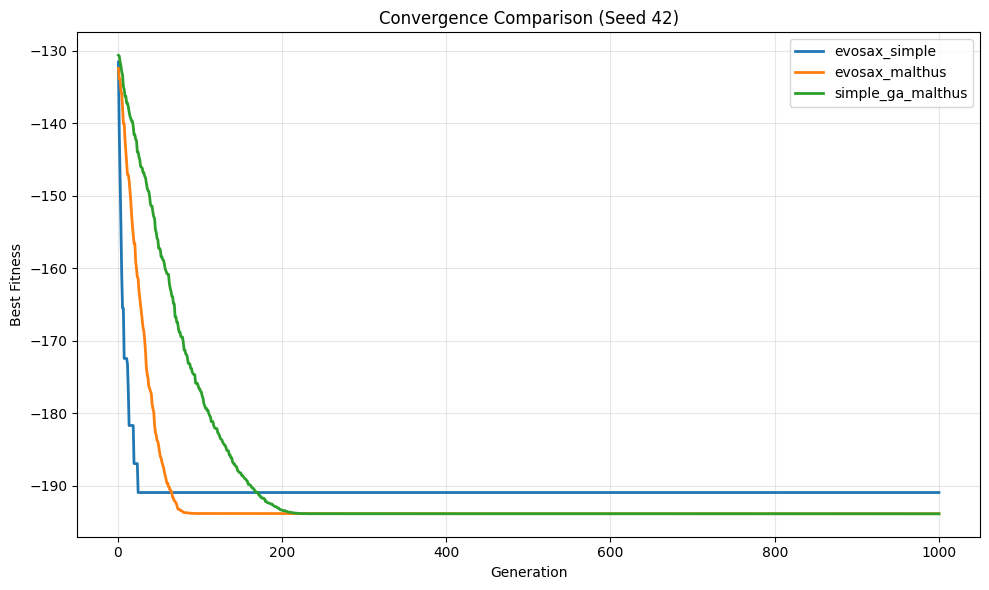

In [5]:
# Plot convergence for first seed
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
comparison.plot_convergence(
    seed_index=0,
    ax=ax,
    title="Convergence Comparison (Seed 42)",
    negate=False,  # False because lower is better
)
plt.tight_layout()
plt.show()

## Part 2: Declarative Configuration with `Composer.from_toml()`

In [6]:
import os

toml_path = "experiment.toml"  # Same directory as notebook

if not os.path.exists(toml_path):
    print(f"TOML file not found at: {toml_path}")
    print(f"Current directory: {os.getcwd()}")
    print(f"Files in current directory: {os.listdir('.')}")
else:
    comparison_toml = Composer.from_toml(
        toml_path,
        pipelines=["blend_ga", "sbx_ga"],
        shared_initial_population=True,
        pop_seed=42,
    )

    print(f"\nLoaded from TOML. Pipelines: {comparison_toml.names}")


Loaded from TOML. Pipelines: ['blend_ga', 'sbx_ga']


In [7]:
conv_data = comparison_toml.convergence_data(seed_index=-1)
for pipeline_name, fitness_history in conv_data.items():
    print(f"\n{pipeline_name}: {len(fitness_history)} generations")
    if len(fitness_history) > 0:
        first_entry = fitness_history[0]
        last_entry = fitness_history[-1]
        print(f"  Gen 1 best: {first_entry['best_fitness']:.6f}")
        print(f"  Gen {int(last_entry['generation'])} best: {last_entry['best_fitness']:.6f}")


blend_ga: 100 generations
  Gen 1 best: -146.597748
  Gen 100 best: -193.856644

sbx_ga: 100 generations
  Gen 1 best: -168.580872
  Gen 100 best: -193.856720


### Compare Both Approaches

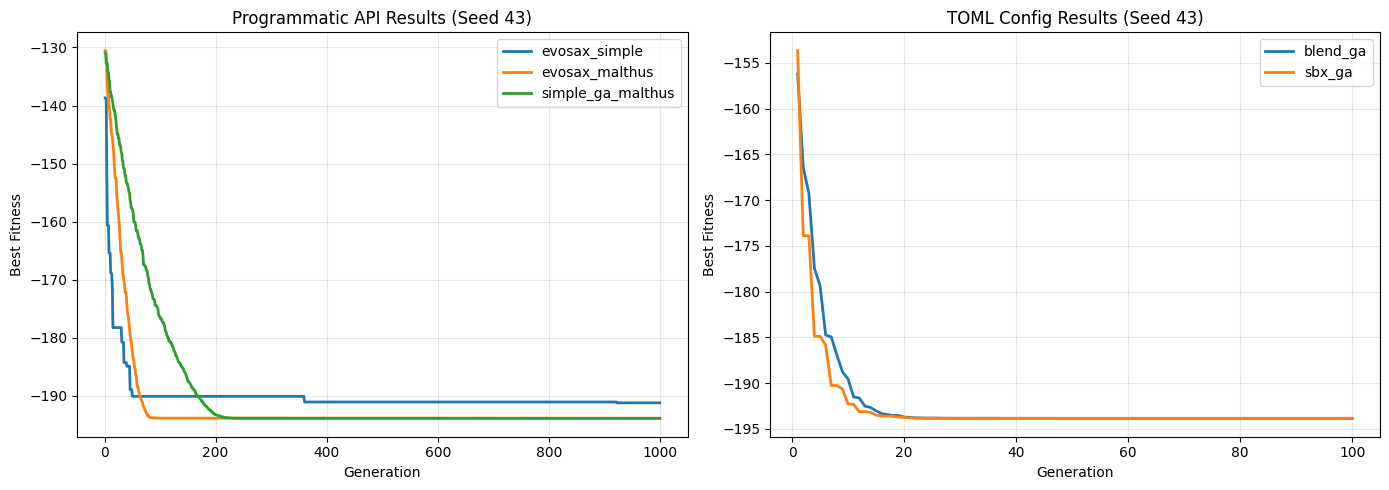

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison.plot_convergence(
    seed_index=2,
    ax=axes[0],
    title="Programmatic API Results (Seed 43)",
)

comparison_toml.plot_convergence(
    seed_index=0,
    ax=axes[1],
    title="TOML Config Results (Seed 43)",
)

plt.tight_layout()
plt.show()

## Key Features

### Engine Registry
- Engines are resolved from string specs via `EngineRegistry`, just like operators use `OperatorCatalog`
- Built-in engine: `"ga"` (standard genetic algorithm via `GeneticEngine`)
- Spec overrides: `"ga:pop_size=100,elitism=4"` — override defaults inline
- `engine_type` parameter in `quick_run()` and `compare()` selects the engine
- Register custom engines at runtime: `registry.register("nsga2", factory)`

### Shared Initial Population
- When `shared_initial_population=True`, both APIs generate the same initial population across all pipelines
- Ensures fair comparison by eliminating initialization variance
- Uses `jax.random.uniform()` with PRNG seed for reproducibility

### Configuration Merging
- TOML `[experiment.shared]` defines defaults (including `engine_type`)
- TOML `[pipelines.*]` override defaults per pipeline
- Programmatic API merges `**shared` with per-pipeline `kwargs`

### Result Analysis
- `ComparisonResult.names` → List of pipeline names
- `ComparisonResult.summary_table()` → Statistics across all runs
- `ComparisonResult.convergence_data()` → Per-seed history
- `ComparisonResult.plot_convergence()` → Matplotlib visualization